In [1]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import gaussian_kde
import tkinter as tk
from tkinter import filedialog
import warnings
from matplotlib.gridspec import GridSpec
import corner
import itertools
warnings.filterwarnings('ignore')

In [2]:
def extraer_datos_de_carpetas(directorio_raiz):
    datos_recopilados = []
    print(f"\nEscaneando directorio y leyendo documentos en: {directorio_raiz}...")

    for root, dirs, files in os.walk(directorio_raiz):
        resumen_file = None
        readme_file = None
        
        for file in files:
            if file.endswith("_resumen.txt"):
                resumen_file = file
            elif file.startswith("README_") and file.endswith(".txt"):
                readme_file = file
                
        if resumen_file and readme_file:
            nombre_planeta = os.path.basename(root).replace("_", " ")
            ruta_resumen = os.path.join(root, resumen_file)
            ruta_readme = os.path.join(root, readme_file)
            
            try:
                # 1. Leer Resumen (Áreas)
                with open(ruta_resumen, 'r', encoding='utf-8') as f:
                    contenido_resumen = f.read()
                
                # Regex para las áreas (Estable, Inestable, Colisión m2)
                a_est_match = re.search(r'rea estable:\s*([0-9\.eE\+\-]+)', contenido_resumen)
                a_inest_match = re.search(r'rea inestable:\s*([0-9\.eE\+\-]+)', contenido_resumen)
                
                # Busca colisión específica con m2, si no la halla, busca colisión general
                a_col_match = re.search(r'rea.*colisi[oó]n.*m2.*:\s*([0-9\.eE\+\-]+)', contenido_resumen, re.IGNORECASE)
                if not a_col_match:
                    a_col_match = re.search(r'rea.*colisi[oó]n.*:\s*([0-9\.eE\+\-]+)', contenido_resumen, re.IGNORECASE)

                a_est = float(a_est_match.group(1)) if a_est_match else 0.0
                a_inest = float(a_inest_match.group(1)) if a_inest_match else 0.0
                a_col = float(a_col_match.group(1)) if a_col_match else 0.0
                
                # 2. Leer README (Parámetros Físicos)
                with open(ruta_readme, 'r', encoding='utf-8') as f:
                    contenido_readme = f.read()
                    
                dist_match = re.search(r'Semi-eje mayor.*:\s*([0-9\.eE\+\-]+)', contenido_readme)
                masa_p_match = re.search(r'Masa del Planeta.*:\s*([0-9\.eE\+\-]+)', contenido_readme)
                pnum_match = re.search(r'CANTIDAD DE PLANETAS.*:\s*(\d+)', contenido_readme)
                
                # Extraer masa de la estrella (si no existe, por defecto asume 1.0)
                masa_e_match = re.search(r'Masa de.*estrella.*:\s*([0-9\.eE\+\-]+)', contenido_readme, re.IGNORECASE)
                masa_estel = float(masa_e_match.group(1)) if masa_e_match else 1.0

                distancia = float(dist_match.group(1))
                masa_planeta = float(masa_p_match.group(1))
                pnum = int(pnum_match.group(1))
                
                datos_recopilados.append({
                    "Planeta": nombre_planeta,
                    "Distancia_UA": distancia,
                    "Masa_Tierra": masa_planeta,
                    "Masa_Estrella": masa_estel,
                    "Num_Planetas": pnum,
                    "Area_Estable_km2": a_est,       # <-- RESTAURADO A SU NOMBRE ORIGINAL
                    "Area_Inestable": a_inest,
                    "Area_Colision_m2": a_col
                })
                
            except (ValueError, AttributeError, FileNotFoundError):
                pass

    df_resultados = pd.DataFrame(datos_recopilados)
    if not df_resultados.empty:
        df_resultados = df_resultados.sort_values(by="Planeta").reset_index(drop=True)
        print(f"Lectura completada. Se extrajeron datos de {len(df_resultados)} sistemas con 6 variables.")
        
    return df_resultados
    if not df_resultados.empty:
        df_resultados = df_resultados.sort_values(by="Planeta").reset_index(drop=True)
        print(f"Lectura completada. Se extrajeron datos validos de {len(df_resultados)} planetas.")
        
    return df_resultados

In [3]:
def graficar_comparacion_multiplicidad(df, base_dir):
    a_total = df['Distancia_UA'].values
    areas = df['Area_Estable_km2'].values
    pnum_total = df['Num_Planetas'].values
    
    # 1. Extraer el nombre del Sistema (Ej: "DMPP-1 b" -> "DMPP-1")
    # Busca el último espacio y toma todo lo que está a la izquierda
    df['Sistema'] = df['Planeta'].apply(lambda x: str(x).rsplit(' ', 1)[0])
    sistemas_unicos = df['Sistema'].unique()
    
    # 2. Generar combinaciones únicas de Marcadores y Colores para cada Sistema
    marcadores_base = ['o', 's', '^', 'D', 'v', 'p', '*', 'h', 'H', 'X', 'd', 'P', '<', '>']
    colores_base = plt.cm.tab20.colors # 20 colores distintos de Matplotlib
    combinaciones = itertools.product(marcadores_base, colores_base)
    
    estilos_sistema = {}
    for sist, (marker, color) in zip(sistemas_unicos, combinaciones):
        estilos_sistema[sist] = {'marker': marker, 'color': color}

    # Estilos originales para el PANEL 0 (Mantenemos la lógica de colores por cantidad)
    estilos_pnum = {
        1: {'marker': 'o', 'color': 'gray', 'label': '1 planeta'},
        2: {'marker': 's', 'color': '#4363d8', 'label': '2 planetas'},
        3: {'marker': '^', 'color': '#e6194b', 'label': '3 planetas'},
        4: {'marker': 'D', 'color': '#3cb44b', 'label': '4 planetas'},
        5: {'marker': 'v', 'color': '#f58231', 'label': '5 planetas'},
        6: {'marker': 'p', 'color': '#911eb4', 'label': '6 planetas'},
        7: {'marker': '*', 'color': '#f032e6', 'label': '7 planetas'}
    }

    # 3. Determinar el número de paneles dinámicamente (1 panel general + N sub-paneles)
    pnums_unicos = sorted(df['Num_Planetas'].unique())
    num_paneles = len(pnums_unicos) + 1
    
    # Crear la figura (Diseño Vertical: num_paneles filas, 1 columna)
    # Aumentamos el ancho a 14 y la altura depende de cuántos gráficos se generen
    fig, axes = plt.subplots(num_paneles, 1, figsize=(14, 6 * num_paneles))
    fig.suptitle("Comparación de Estabilidad Orbital por Multiplicidad", fontsize=22, fontweight='bold', y=0.98)
    
    # Asegurar que axes sea iterable (por si solo hay 1 panel, aunque habrá más)
    if num_paneles == 1:
        axes = [axes]
        
    # Definir los límites fijos basados en la totalidad de los datos compartan escala
    xlims = (a_total.min() * 0.5, a_total.max() * 2.0) if len(a_total) > 0 else (0.1, 100)
    ylims = (areas.min() * 0.5, areas.max() * 2.0) if len(areas) > 0 else (1e5, 1e10)

    # ==========================================
    # PANEL 0: General (Mantiene la estructura original)
    # ==========================================
    ax_all = axes[0]
    ax_all.set_title("Todos los sistemas (Clasificados por Multiplicidad)", fontsize=16, fontweight='bold')
    
    for p_num in pnums_unicos:
        mask = pnum_total == p_num
        props = estilos_pnum.get(p_num, {'marker': 'X', 'color': 'black', 'label': f'{p_num} planetas'})
        ax_all.scatter(a_total[mask], areas[mask], marker=props['marker'], color=props['color'], 
                       s=100, alpha=0.8, edgecolor='black', label=props['label'], zorder=3)
        
    # Leyenda movida fuera de la caja para no tapar los puntos
    ax_all.legend(loc='upper left', bbox_to_anchor=(1.02, 1), frameon=True, shadow=True, title="Simbología")

    # ==========================================
    # PANELES 1 al N: De arriba hacia abajo (Marcadores por Sistema)
    # ==========================================
    for i, p_num in enumerate(pnums_unicos):
        ax = axes[i+1]
        df_sub = df[df['Num_Planetas'] == p_num]
        
        ax.set_title(f"Sistemas con {p_num} planetas", fontsize=16, fontweight='bold')
        
        # --- Calcular el KDE (Zonas de densidad) ---
        a_sub = df_sub['Distancia_UA'].values
        if len(a_sub) >= 2:
            log_a = np.log10(a_sub)
            try:
                kde = gaussian_kde(log_a)
                x_eval = np.linspace(log_a.min(), log_a.max(), 1000)
                y_eval = kde(x_eval)

                idx_max = np.argmax(y_eval)
                a_pico = 10**x_eval[idx_max]

                umbral = y_eval.max() * 0.5
                indices_rango = np.where(y_eval > umbral)[0]
                
                if len(indices_rango) > 0:
                    a_min_rango = 10**x_eval[indices_rango[0]]
                    a_max_rango = 10**x_eval[indices_rango[-1]]
                    texto_rango = f'Concentración: {a_min_rango:.2f} - {a_max_rango:.2f} UA'
                    
                    ax.axvspan(a_min_rango, a_max_rango, color='gray', alpha=0.15, label=texto_rango, zorder=0)
                    ax.axvline(a_pico, color='red', linestyle=':', linewidth=1.5, label=f'Pico: {a_pico:.2f} UA', zorder=1)
            except np.linalg.LinAlgError:
                pass 

        # --- Graficar puntos asignando el marcador según el Sistema ---
        sistemas_en_este_panel = df_sub['Sistema'].unique()
        
        for sist in sistemas_en_este_panel:
            df_sist = df_sub[df_sub['Sistema'] == sist]
            props = estilos_sistema[sist]
            
            ax.scatter(df_sist['Distancia_UA'], df_sist['Area_Estable_km2'], 
                       marker=props['marker'], color=props['color'], 
                       s=110, alpha=0.85, edgecolor='black', label=sist, zorder=3)
        
        # Leyenda colocada a la derecha de la gráfica. 
        # Utilizamos ncol=2 (dos columnas) por si hay decenas de sistemas en un solo panel.
        ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), frameon=True, 
                  shadow=True, title="Nombre del Sistema", ncol=2, fontsize=9)

    # ==========================================
    # ESTÉTICA GENERAL DE TODOS LOS EJES
    # ==========================================
    for ax in axes:
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlim(xlims)
        ax.set_ylim(ylims)
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:g}'))
        
        # Añadimos una cuadrícula (grid) suave para facilitar la lectura
        ax.grid(True, which="both", ls="--", alpha=0.3, zorder=0)
        
        ax.set_xlabel("log[a] (UA)", fontsize=12, fontweight='bold')
        ax.set_ylabel(r"log[Áreas Estables] (km$^2$)", fontsize=12, fontweight='bold')

    # Ajustamos el layout para dar espacio a las leyendas laterales
    plt.tight_layout(rect=[0, 0.03, 0.85, 0.98]) 
    
    # Guardar gráficos
    ruta_png = os.path.join(base_dir, "Comparacion_Multiplicidad_Vertical.png")
    ruta_pdf = os.path.join(base_dir, "Comparacion_Multiplicidad_Vertical.pdf")
    plt.savefig(ruta_png, dpi=300, bbox_inches='tight')
    plt.savefig(ruta_pdf, format="pdf", bbox_inches='tight')
    plt.show()
    plt.close()

In [4]:
def graficar_estabilidad_vs_masa(df, base_dir):
    masas = df['Masa_Tierra'].values
    areas = df['Area_Estable_km2'].values
    
    validos = (masas >= 1.0) & (masas <= 300.0) & (areas > 0)
    m_filtro = masas[validos]
    a_filtro = areas[validos]
    
    if len(m_filtro) == 0:
        print("No hay suficientes planetas en el rango de 1 a 300 masas terrestres.")
        return

    fig, ax = plt.subplots(figsize=(12, 8))
    
    ax.axvspan(1, 10, color='gray', alpha=0.15, label='Rocosos (1 - 10 $M_\oplus$)')
    ax.axvspan(10, 50, color='royalblue', alpha=0.15, label='Neptunianos (10 - 50 $M_\oplus$)')
    ax.axvspan(50, 300, color='firebrick', alpha=0.15, label='Gigantes Gaseosos (50 - 300 $M_\oplus$)')

    mask_rocosos = (m_filtro >= 1) & (m_filtro <= 10)
    mask_neptuno = (m_filtro > 10) & (m_filtro <= 50)
    mask_gigante = (m_filtro > 50) & (m_filtro <= 300)

    if np.any(mask_rocosos):
        ax.scatter(m_filtro[mask_rocosos], a_filtro[mask_rocosos], marker='o', color='dimgray', 
                   s=90, edgecolor='black', alpha=0.85, label='Planetas Rocosos', zorder=3)
    if np.any(mask_neptuno):
        ax.scatter(m_filtro[mask_neptuno], a_filtro[mask_neptuno], marker='s', color='dodgerblue', 
                   s=90, edgecolor='black', alpha=0.85, label='Planetas Neptunianos', zorder=3)
    if np.any(mask_gigante):
        ax.scatter(m_filtro[mask_gigante], a_filtro[mask_gigante], marker='D', color='tomato', 
                   s=90, edgecolor='black', alpha=0.85, label='Gigantes Gaseosos', zorder=3)

    ax.set_xscale('log')
    ax.set_yscale('log')
    
    ax.set_xlim(0.8, 350)
    ax.set_ylim(a_filtro.min() * 0.5, a_filtro.max() * 2.0)

    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:g}'))
    ax.set_xticks([1, 10, 50, 100, 300])

    ax.set_title("Estabilidad Orbital segun Categoria de Masa", fontsize=15, fontweight='bold', pad=20)
    ax.set_xlabel(r"Masa del Planeta (Masas Terrestres, $M_\oplus$)", fontsize=12, fontweight='bold')
    ax.set_ylabel(r"log[Areas Estables] (km$^2$)", fontsize=12, fontweight='bold')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True, shadow=True, title="Categorias")
    
    plt.tight_layout()
    
    ruta_png = os.path.join(base_dir, "Estabilidad_vs_Masa_Zonas.png")
    ruta_pdf = os.path.join(base_dir, "Estabilidad_vs_Masa_Zonas.pdf")
    plt.savefig(ruta_png, dpi=300, bbox_inches='tight')
    plt.savefig(ruta_pdf, format="pdf", bbox_inches='tight')
    plt.show()
    plt.close()

In [5]:
def plot_islands_of_stability(df, base_dir):
    """
    Genera un mapa de contornos de densidad 2D (KDE) vertical.
    Panel superior: Visión global.
    Paneles inferiores: Filtrados por multiplicidad, con marcadores por sistema.
    """
    # 1. Filtrar datos con áreas válidas (>0) para evitar log(0)
    df_f = df[df['Area_Estable_km2'] > 0].copy()
    if df_f.empty:
        print("No hay datos válidos con Área > 0 para graficar.")
        return

    # 2. Extraer el nombre del Sistema (Ej: "DMPP-1 b" -> "DMPP-1")
    df_f['Sistema'] = df_f['Planeta'].apply(lambda x: str(x).rsplit(' ', 1)[0])
    sistemas_unicos = df_f['Sistema'].unique()
    
    # 3. Generar combinaciones únicas de Marcadores y Colores para cada Sistema
    marcadores_base = ['o', 's', '^', 'D', 'v', 'p', '*', 'h', 'H', 'X', 'd', 'P', '<', '>']
    colores_base = plt.cm.tab20.colors # 20 colores distintos
    combinaciones = itertools.product(marcadores_base, colores_base)
    
    estilos_sistema = {}
    for sist, (marker, color) in zip(sistemas_unicos, combinaciones):
        estilos_sistema[sist] = {'marker': marker, 'color': color}

    # 4. Determinar número de paneles
    pnums_unicos = sorted(df_f['Num_Planetas'].unique())
    num_paneles = len(pnums_unicos) + 1
    
    # --- CAMBIO 1: Figura mucho más ancha e intervalos más altos ---
    # Tamaño aumentado a 18 de ancho y 10 de alto por cada panel
    fig, axes = plt.subplots(num_paneles, 1, figsize=(18, 10 * num_paneles))
    fig.suptitle("Mapas de Contorno 2D: Islas de Estabilidad por Multiplicidad", 
                 fontsize=24, fontweight='bold', y=0.98)
    
    if num_paneles == 1:
        axes = [axes]

    # --- CAMBIO 2: Márgenes más amplios (Padding de 0.4) ---
    x_all = np.log10(df_f['Distancia_UA'])
    y_all = np.log10(df_f['Masa_Tierra'])
    xlims = (x_all.min() - 0.4, x_all.max() + 0.4)
    ylims = (y_all.min() - 0.4, y_all.max() + 0.4)

    # ==========================================
    # FUNCIÓN INTERNA PARA DIBUJAR CADA PANEL
    # ==========================================
    def dibujar_panel(ax, df_subset, titulo, es_general=False):
        x = np.log10(df_subset['Distancia_UA'].values)
        y = np.log10(df_subset['Masa_Tierra'].values)
        weights = np.log10(df_subset['Area_Estable_km2'].values)
        
        # --- A. MAPA DE CONTORNOS (KDE 2D) ---
        # Se requieren al menos 3 puntos y varianza para evitar matrices singulares
        if len(df_subset) > 3 and x.var() > 0 and y.var() > 0:
            try:
                xy = np.vstack([x, y])
                
                # --- CAMBIO 3: Factor de Suavizado (Bandwidth = 0.45) ---
                kde = gaussian_kde(xy, weights=weights, bw_method=0.45)
                
                # Crear la malla base (Resolución aumentada a 150j)
                X, Y = np.mgrid[xlims[0]:xlims[1]:150j, ylims[0]:ylims[1]:150j]
                positions = np.vstack([X.ravel(), Y.ravel()])
                Z = np.reshape(kde(positions).T, X.shape)
                
                # Graficar contornos (Niveles aumentados a 25)
                contour = ax.contourf(X, Y, Z, levels=25, cmap='viridis', alpha=0.85)
                
                # Agregar barra de color ajustada
                cbar = fig.colorbar(contour, ax=ax, pad=0.02, aspect=30)
                cbar.set_label('Densidad del Área (KDE)', fontsize=12)
            except np.linalg.LinAlgError:
                pass # Si los datos son colineales, omite el fondo pero dibuja los puntos

        # --- B. PUNTOS DE DISPERSIÓN (SCATTER POR SISTEMA) ---
        sistemas_en_panel = df_subset['Sistema'].unique()
        for sist in sistemas_en_panel:
            df_sist = df_subset[df_subset['Sistema'] == sist]
            props = estilos_sistema[sist]
            
            # Etiqueta solo si estamos en un sub-panel (el panel 0 tendría demasiadas)
            label = sist if not es_general else None
            
            # Puntos más grandes (s=90)
            ax.scatter(np.log10(df_sist['Distancia_UA']), 
                       np.log10(df_sist['Masa_Tierra']), 
                       marker=props['marker'], color=props['color'], 
                       s=90, edgecolor='white', linewidth=1.0, label=label, zorder=5)

        # --- C. LÍNEAS DE LÍMITES FÍSICOS ---
        ax.axhline(y=np.log10(10), color='cyan', linestyle='--', linewidth=2, 
                   label='Límite Rocoso / Neptuniano', zorder=4)
        ax.axhline(y=np.log10(50), color='magenta', linestyle='--', linewidth=2, 
                   label='Límite Neptuniano / Gigante', zorder=4)

        # --- D. ESTÉTICA DEL EJE ---
        ax.set_title(titulo, fontsize=18, fontweight='bold', pad=15)
        ax.set_xlim(xlims)
        ax.set_ylim(ylims)
        ax.set_xlabel("log[Distancia] (UA)", fontsize=14)
        ax.set_ylabel(r"log[Masa Planetaria] ($M_\oplus$)", fontsize=14)
        ax.grid(True, which="both", ls="--", color='white', alpha=0.3, zorder=0)

        # --- E. LEYENDAS ---
        # Posicionamos la leyenda lejos (bbox a 1.22) para que no choque con la Colorbar
        if not es_general:
            ax.legend(loc='upper left', bbox_to_anchor=(1.22, 1), frameon=True, 
                      shadow=True, title="Sistemas", ncol=2, fontsize=10)
        else:
            # En el panel general, solo mostramos la leyenda de las líneas divisorias
            handles, labels = ax.get_legend_handles_labels()
            line_handles = [h for h, l in zip(handles, labels) if 'Límite' in l]
            line_labels = [l for l in labels if 'Límite' in l]
            if line_handles:
                ax.legend(line_handles, line_labels, loc='upper left', 
                          bbox_to_anchor=(1.22, 1), frameon=True, shadow=True, fontsize=10)

    # ==========================================
    # EJECUCIÓN DE LOS PANELES
    # ==========================================
    
    # PANEL 0: Todos los sistemas (Visión Global)
    dibujar_panel(axes[0], df_f, "Visión Global: Todos los sistemas", es_general=True)

    # PANELES 1 al N: Filtrados por cantidad de planetas
    for i, pnum in enumerate(pnums_unicos):
        df_sub = df_f[df_f['Num_Planetas'] == pnum]
        dibujar_panel(axes[i+1], df_sub, f"Sistemas con {pnum} planetas", es_general=False)

    # Ajuste del lienzo para dar espacio a colorbars y leyendas derechas
    plt.tight_layout(rect=[0, 0.03, 0.82, 0.98]) 
    
    # Guardar gráficos
    ruta_png = os.path.join(base_dir, "Mapa_Islas_Estabilidad_Vertical_Expandido.png")
    ruta_pdf = os.path.join(base_dir, "Mapa_Islas_Estabilidad_Vertical_Expandido.pdf")
    plt.savefig(ruta_png, dpi=300, bbox_inches='tight')
    plt.savefig(ruta_pdf, format="pdf", bbox_inches='tight')
    
    plt.show()
    plt.close(fig)

In [6]:
def plot_corner_6D(df, base_dir):
    """
    Genera un Corner Plot de 6 dimensiones relacionando Masas, Distancia y Áreas.
    """
    # Filtramos para tener datos con física válida (masa del planeta entre 1 y 300)
    validos = (df['Masa_Tierra'] >= 1.0) & (df['Masa_Tierra'] <= 300.0)
    df_f = df[validos]

    if len(df_f) < 3:
        print("No hay suficientes datos para generar el Corner Plot 6D.")
        return

   # Transformaciones logarítmicas (sumamos +1 para evitar errores de log(0))
    log_a = np.log10(df_f['Distancia_UA'].values)
    log_mp = np.log10(df_f['Masa_Tierra'].values)
    m_star = df_f['Masa_Estrella'].values 
    
    # --- CAMBIO AQUÍ: Ahora lee 'Area_Estable_km2' ---
    log_area_est = np.log10(df_f['Area_Estable_km2'].values + 1)
    # ------------------------------------------------
    
    log_area_inest = np.log10(df_f['Area_Inestable'].values + 1)
    log_area_col = np.log10(df_f['Area_Colision_m2'].values + 1)

    # Matriz de 6 dimensiones
    muestras = np.vstack([log_a, log_mp, m_star, log_area_est, log_area_inest, log_area_col]).T

    # Etiquetas formales para publicación
    labels = [
        r"$\log[a]$ (UA)", 
        r"$\log[M_p]$ ($M_\oplus$)", 
        r"$M_{star}$", 
        r"$\log[A_{estable}]$", 
        r"$\log[A_{inestable}]$", 
        r"$\log[A_{col-m2}]$"
    ]

    # Generar el gráfico (requerirá una figura más grande al ser de 6x6 paneles)
    fig = plt.figure(figsize=(20, 14))
    
    fig = corner.corner(
        muestras,
        fig=fig,
        labels=labels,
        label_kwargs={"fontsize": 12, "fontweight": "bold"},
        show_titles=True,
        title_kwargs={"fontsize": 10},
        title_fmt=".2f",
        smooth=1.0,
        bins=30,
        color="#8c564b", # Un color marrón rojizo elegante para distinguir de los otros
        quantiles=[0.16, 0.5, 0.84],
        fill_contours=True,
        plot_datapoints=False,
        plot_density=True
    )

    fig.suptitle("Matriz de Correlación 6D: Parámetros Físicos vs Zonas Dinámicas", fontsize=20, fontweight='bold', y=1.03)

    ruta_png = os.path.join(base_dir, "Corner_Plot_6D_Completo.png")
    ruta_pdf = os.path.join(base_dir, "Corner_Plot_6D_Completo.pdf")
    plt.savefig(ruta_png, dpi=300, bbox_inches='tight')
    plt.savefig(ruta_pdf, format="pdf", bbox_inches='tight')
    
    plt.show()
    plt.close(fig)

In [7]:
def plot_relaciones_mu_2d(df, base_dir):
    """
    Genera una matriz de 2x2 gráficos de dispersión analizando 
    la relación entre las masas reducidas (mu1, mu2), la distancia y las áreas.
    Ejes normalizados aplicando logaritmo matemático (np.log10) en lugar de escalas visuales.
    """
    # 1. Filtramos datos válidos
    validos = (df['Area_Estable_km2'] > 0)
    df_f = df[validos].copy()

    if len(df_f) == 0:
        print("No hay datos suficientes para generar los gráficos de mu.")
        return

    # 2. Cálculos físicos (Replicando tu clase SistemaPlanetario)
    m1_kg = df_f['Masa_Estrella'] * 1.989E30 
    m2_kg = df_f['Masa_Tierra'] * 5.972E24
    
    df_f['mu2'] = m2_kg / (m1_kg + m2_kg)
    df_f['mu1'] = 1.0 - df_f['mu2']
    
    # 3. TRANSFORMACIÓN MATEMÁTICA (Adiós a las potencias de 10)
    mu1 = df_f['mu1'].values
    log_mu2 = np.log10(df_f['mu2'].values)
    log_a_au = np.log10(df_f['Distancia_UA'].values)
    log_areas = np.log10(df_f['Area_Estable_km2'].values)

    # 4. Configuración del Lienzo (2x2)
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    fig.suptitle(r"Análisis Dinámico: Influencia de las Masas Reducidas ($\mu_1, \mu_2$)", 
                 fontsize=18, fontweight='bold', y=0.98)

    # ---------------------------------------------------------
    # Panel 1: mu1 vs log[Distancia] (mu1 no lleva logaritmo porque es ~ 1)
    # ---------------------------------------------------------
    ax1 = axes[0, 0]
    ax1.scatter(mu1, log_a_au, alpha=0.7, color='teal', edgecolor='black', s=50)
    ax1.set_title(r"$\mu_1$ vs $\log[$Distancia$]$", fontsize=14, fontweight='bold')
    ax1.set_xlabel(r"$\mu_1$ (Estrella Principal)", fontsize=12)
    ax1.set_ylabel(r"$\log[$Distancia (UA)$]$", fontsize=12)
    
    # Formateo estricto para mu1 (Evita que redondee a 1)
    ax1.ticklabel_format(useOffset=False, style='plain', axis='x')
    ax1.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.6f'))
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

    # ---------------------------------------------------------
    # Panel 2: log[mu2] vs log[Distancia]
    # ---------------------------------------------------------
    ax2 = axes[0, 1]
    ax2.scatter(log_mu2, log_a_au, alpha=0.7, color='coral', edgecolor='black', s=50)
    ax2.set_title(r"$\log[\mu_2]$ vs $\log[$Distancia$]$", fontsize=14, fontweight='bold')
    ax2.set_xlabel(r"$\log[\mu_2]$ (Planeta / Masa Secundaria)", fontsize=12)
    ax2.set_ylabel(r"$\log[$Distancia (UA)$]$", fontsize=12)

    # ---------------------------------------------------------
    # Panel 3: log[Distancia] vs log[Área Estable]
    # ---------------------------------------------------------
    ax3 = axes[1, 0]
    ax3.scatter(log_a_au, log_areas, alpha=0.7, color='mediumpurple', edgecolor='black', s=50)
    ax3.set_title(r"$\log[$Distancia$]$ vs $\log[$Área Estable$]$", fontsize=14, fontweight='bold')
    ax3.set_xlabel(r"$\log[$Distancia (UA)$]$", fontsize=12)
    ax3.set_ylabel(r"$\log[$Área Estable (km$^2$)$]$", fontsize=12)

    # ---------------------------------------------------------
    # Panel 4: log[mu2] vs log[Área Estable]
    # ---------------------------------------------------------
    ax4 = axes[1, 1]
    ax4.scatter(log_mu2, log_areas, alpha=0.7, color='goldenrod', edgecolor='black', s=50)
    ax4.set_title(r"$\log[\mu_2]$ vs $\log[$Área Estable$]$", fontsize=14, fontweight='bold')
    ax4.set_xlabel(r"$\log[\mu_2]$ (Planeta / Masa Secundaria)", fontsize=12)
    ax4.set_ylabel(r"$\log[$Área Estable (km$^2$)$]$", fontsize=12)

    # Ajuste de layout
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    # Guardar gráficos
    ruta_png = os.path.join(base_dir, "Relaciones_MasaReducida_2D.png")
    ruta_pdf = os.path.join(base_dir, "Relaciones_MasaReducida_2D.pdf")
    plt.savefig(ruta_png, dpi=300, bbox_inches='tight')
    plt.savefig(ruta_pdf, format="pdf", bbox_inches='tight')
    
    plt.show()
    plt.close(fig)

In [ ]:
def plot_3d_area_estable(df, base_dir):
    """
    Genera un gráfico de dispersión 3D relacionando:
    X = log10[Distancia (UA)] (Normalizado)
    Y = Masa Reducida (mu1) (Normalizado)
    Z = log10[Área Estable (km2)] (Normalizado)
    """
    # 1. Filtrar datos válidos usando tu columna exacta
    df_f = df[df['Area_Estable_km2'] > 0].copy()
    
    if df_f.empty:
        print("No hay datos válidos con Área > 0 para graficar en 3D.")
        return

    # 2. Cálculos físicos y logaritmos iniciales
    m1_kg = df_f['Masa_Estrella'] * 1.989E30  
    m2_kg = df_f['Masa_Tierra'] * 5.972E24 
    
    df_f['mu1'] = 1.0 - (m2_kg / (m1_kg + m2_kg))
    df_f['log_dist'] = np.log10(df_f['Distancia_UA'])
    df_f['log_area'] = np.log10(df_f['Area_Estable_km2'])

    # 3. NORMALIZACIÓN MIN-MAX [0, 1] GLOBAL
    # Fórmula: (Valor - Mínimo) / (Máximo - Mínimo)
    df_f['X_norm'] = (df_f['log_dist'] - df_f['log_dist'].min()) / (df_f['log_dist'].max() - df_f['log_dist'].min())
    df_f['Y_norm'] = (df_f['mu1'] - df_f['mu1'].min()) / (df_f['mu1'].max() - df_f['mu1'].min())
    df_f['Z_norm'] = (df_f['log_area'] - df_f['log_area'].min()) / (df_f['log_area'].max() - df_f['log_area'].min())

    # 4. Configurar el lienzo 3D
    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection='3d')
    
    # Extraer multiplicidades para la leyenda
    pnums_unicos = sorted(df_f['Num_Planetas'].unique())
    marcadores = ['*', 'o', '^', 's', 'D', 'p', 'h']
    colores = plt.cm.tab10.colors
    
    # 5. Graficar los datos normalizados
    for i, pnum in enumerate(pnums_unicos):
        df_sub = df_f[df_f['Num_Planetas'] == pnum]
        
        ax.scatter(df_sub['X_norm'], 
                   df_sub['Y_norm'], 
                   df_sub['Z_norm'], 
                   marker=marcadores[i % len(marcadores)], 
                   color=colores[i % len(colores)],
                   s=80, alpha=0.85, edgecolors='black', linewidth=0.6,
                   label=f'Sistemas con {pnum} planetas')

    # 6. Estética y Etiquetas de los Ejes
    ax.set_title("Relación 3D Normalizada [0,1]: Distancia, $\mu_1$ y Área Estable", fontsize=16, fontweight='bold', pad=20)
    
    ax.set_xlabel('log[Distancia] (Normalizada)', fontsize=12, fontweight='bold', labelpad=10)
    ax.set_ylabel(r'$\mu_1$ (Normalizada)', fontsize=12, fontweight='bold', labelpad=10)
    ax.set_zlabel('log[Área] (Normalizada)', fontsize=12, fontweight='bold', labelpad=10)

    # Como ahora todos los ejes van de 0 a 1, un formateo genérico de 2 decimales es el ideal
    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
    ax.zaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

    # Ángulo de visión inicial 
    ax.view_init(elev=20, azim=-45)

    # 7. Leyenda
    ax.legend(title="Multiplicidad", loc='upper right', frameon=True, shadow=True)

    # 8. Guardar y mostrar
    ruta_png = os.path.join(base_dir, "Relacion_3D_Normalizada.png")
    ruta_pdf = os.path.join(base_dir, "Relacion_3D_Normalizada.pdf")
    plt.savefig(ruta_png, dpi=300, bbox_inches='tight')
    plt.savefig(ruta_pdf, format="pdf", bbox_inches='tight')
    
    plt.show()
    plt.close(fig)

In [9]:
if __name__ == "__main__":
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)

    print("Esperando seleccion de carpeta...")
    
    DIRECTORIO_RAIZ = filedialog.askdirectory(title="Selecciona la carpeta de resultados")

    if DIRECTORIO_RAIZ:
        df_datos = extraer_datos_de_carpetas(DIRECTORIO_RAIZ)
        
        if not df_datos.empty:
            print("\nGenerando grafico de comparacion por multiplicidad...")
            graficar_comparacion_multiplicidad(df_datos, DIRECTORIO_RAIZ)
            
            print("Generando grafico de zonas de masa...")
            graficar_estabilidad_vs_masa(df_datos, DIRECTORIO_RAIZ)
            
            print("Generando mapa de contornos de islas de estabilidad...")
            plot_islands_of_stability(df_datos, DIRECTORIO_RAIZ)
            
            # --- NUEVA LLAMADA AGREGADA AQUÍ ---
            print("Generando Gráficos KDE 1D y 2D combinados (Marginales)...")
            plot_corner_6D(df_datos, DIRECTORIO_RAIZ)
            # -----------------------------------
            
            print(f"\nProceso finalizado. Graficos guardados en:\n{DIRECTORIO_RAIZ}")
    else:
        print("\nOperacion cancelada por el usuario.")

Esperando seleccion de carpeta...

Escaneando directorio y leyendo documentos en: C:/Users/darkm/Desktop/archivos_Investigación/Investigacion/Troyanos/Resultados_Estrellas_F...


In [11]:
if __name__ == "__main__":
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)

    print("Esperando seleccion de carpeta...")
    
    DIRECTORIO_RAIZ = filedialog.askdirectory(title="Selecciona la carpeta de resultados")

    if DIRECTORIO_RAIZ:
        df_datos = extraer_datos_de_carpetas(DIRECTORIO_RAIZ)
        
        if not df_datos.empty:
            print("\nGenerando grafico de comparacion por multiplicidad...")
            graficar_comparacion_multiplicidad(df_datos, DIRECTORIO_RAIZ)
            
            print("Generando grafico de zonas de masa...")
            graficar_estabilidad_vs_masa(df_datos, DIRECTORIO_RAIZ)
            
            print("Generando mapa de contornos de islas de estabilidad...")
            plot_islands_of_stability(df_datos, DIRECTORIO_RAIZ)
            
            # --- NUEVA LLAMADA AGREGADA AQUÍ ---
            print("Generando Gráficos KDE 1D y 2D combinados (Marginales)...")
            plot_corner_6D(df_datos, DIRECTORIO_RAIZ)
            # -----------------------------------
            
            print(f"\nProceso finalizado. Graficos guardados en:\n{DIRECTORIO_RAIZ}")
        else:
            print("\nNo se encontraron datos validos en la carpeta seleccionada.")
    else:
        print("\nOperacion cancelada por el usuario.")

Esperando seleccion de carpeta...

Escaneando directorio y leyendo documentos en: C:/Users/darkm/Desktop/archivos_Investigación/Investigacion/Troyanos/Resultados_Estrellas_F...

No se encontraron datos validos en la carpeta seleccionada.


Esperando seleccion de carpeta...

Escaneando directorio y leyendo documentos en: C:/Users/darkm/Desktop/archivos_Investigación/Investigacion/Resultados_-con_sistemas_2_planetas/Resultados_Estrellas_M...
Lectura completada. Se extrajeron datos de 314 sistemas con 6 variables.
Filtro aplicado: Quedan 175 registros con 3 o más planetas.

Generando grafico de comparacion por multiplicidad...


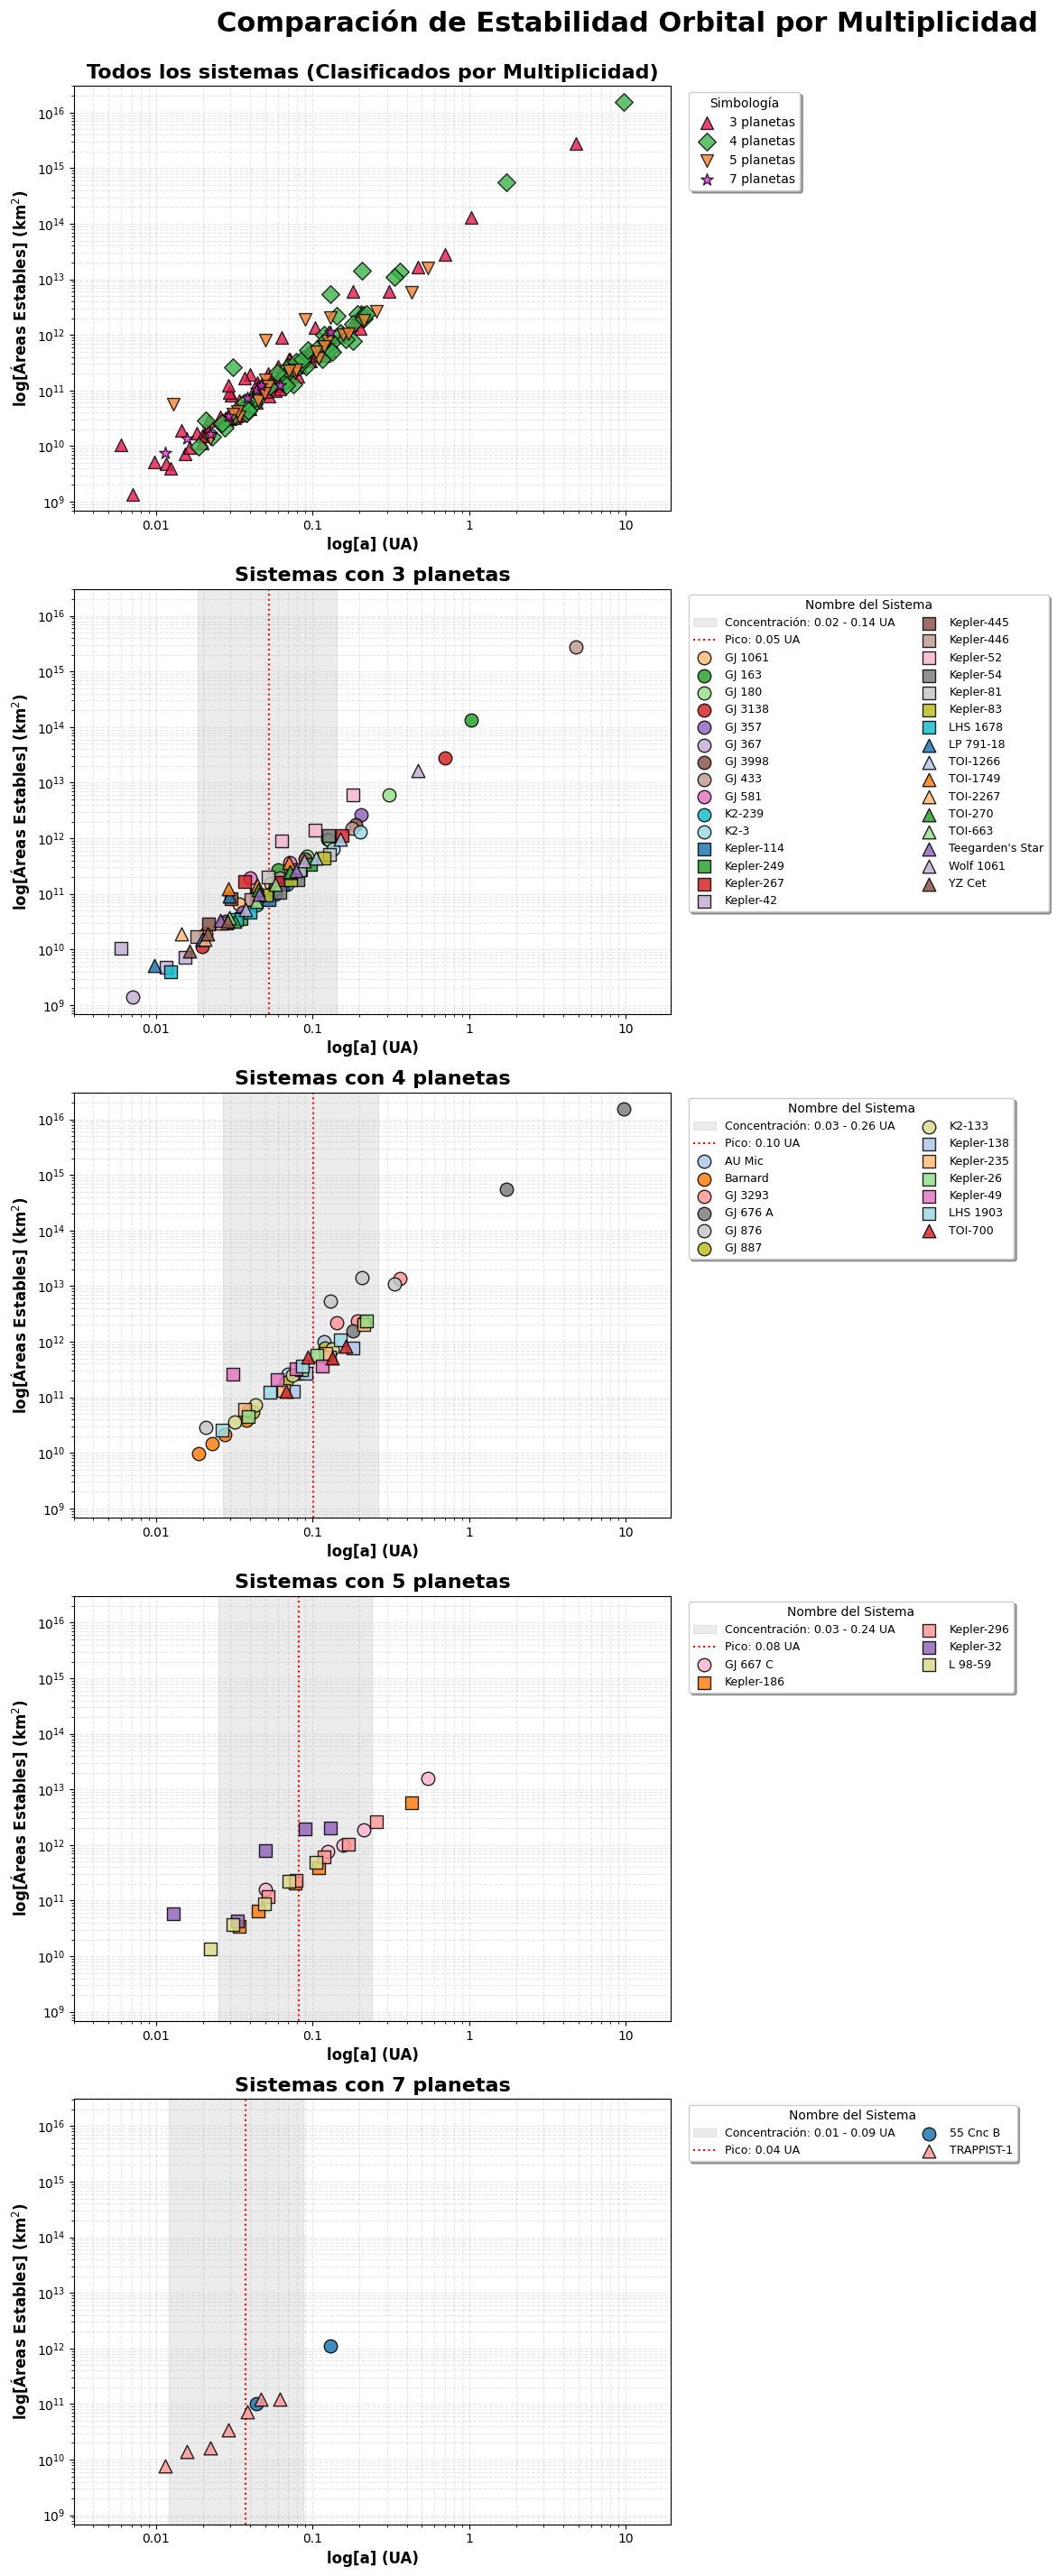

Generando grafico de zonas de masa...


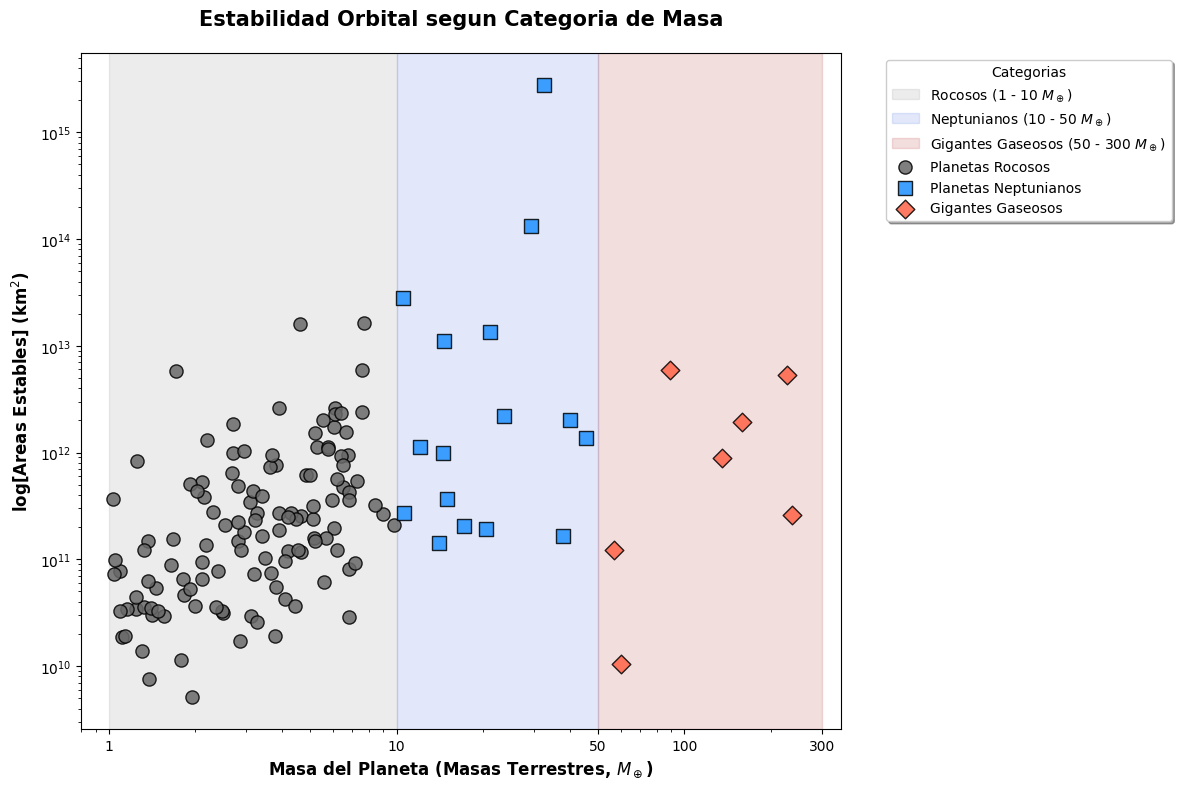


Proceso finalizado. Graficos guardados en:
C:/Users/darkm/Desktop/archivos_Investigación/Investigacion/Resultados_-con_sistemas_2_planetas/Resultados_Estrellas_M


In [ ]:
if __name__ == "__main__":
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)

    print("Esperando seleccion de carpeta...")
    
    DIRECTORIO_RAIZ = filedialog.askdirectory(title="Selecciona la carpeta de resultados")

    if DIRECTORIO_RAIZ:
        df_datos = extraer_datos_de_carpetas(DIRECTORIO_RAIZ)
        
        # --- NUEVO FILTRO AGREGADO AQUÍ ---
        # Filtramos para quedarnos solo con sistemas que tengan 3 o más planetas
        if not df_datos.empty:
            df_datos = df_datos[df_datos['Num_Planetas'] >= 3]
            print(f"Filtro aplicado: Quedan {len(df_datos)} registros con 3 o más planetas.")
        # ----------------------------------
        
        if not df_datos.empty:
            print("\nGenerando grafico de comparacion por multiplicidad...")
            graficar_comparacion_multiplicidad(df_datos, DIRECTORIO_RAIZ)
            
            print("Generando grafico de zonas de masa...")
            graficar_estabilidad_vs_masa(df_datos, DIRECTORIO_RAIZ)
            
            # Si tienes las otras funciones (KDE 2D, Corner plot) las puedes dejar aquí también
            
            print(f"\nProceso finalizado. Graficos guardados en:\n{DIRECTORIO_RAIZ}")
        else:
            print("\nNo se encontraron datos validos en la carpeta seleccionada (o ninguno cumple con tener 3 o más planetas).")
    else:
        print("\nOperacion cancelada por el usuario.")

In [ ]:
if __name__ == "__main__":
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)

    print("Esperando seleccion de carpeta...")
    
    DIRECTORIO_RAIZ = filedialog.askdirectory(title="Selecciona la carpeta de resultados")

    if DIRECTORIO_RAIZ:
        df_datos = extraer_datos_de_carpetas(DIRECTORIO_RAIZ)
        
        if not df_datos.empty:
            print("\nGenerando grafico de comparacion por multiplicidad...")
            graficar_comparacion_multiplicidad(df_datos, DIRECTORIO_RAIZ)
            
    
            
            print("Generando mapa de contornos de islas de estabilidad...")
            plot_islands_of_stability(df_datos, DIRECTORIO_RAIZ)
            
    else:
        print("\nOperacion cancelada por el usuario.")

Esperando seleccion de carpeta...

Escaneando directorio y leyendo documentos en: C:/Users/darkm/Desktop/archivos_Investigación/Investigacion/Resultados_-con_sistemas_2_planetas/Resultados_Estrellas_K...

No se encontraron datos validos en la carpeta seleccionada.
